# FMSR Class 4 – Descriptive Statistics
**Minor Data Driven Decision Making in Business – uitwerking van de opdrachten**

Dit notebook werkt de vier opdrachten uit de slides van Class 4 uit:

1. **Exercise Descriptives (1)** – maten van centrale tendens + mean vs. median
2. **Exercise Descriptives (2)** – spreidingsmaten, visualisatie, welke variabele varieert meer
3. **Exercise Coefficient of Variation** – CV van lengte en cijfer (het `.py`-script ingevuld)
4. **Exercise Olympic Athletes** – kansen berekenen met de normale verdeling

Werkwijze per stap: eerst *wat* en *waarom*, dan de code, daarna *wat betekent de output* en *wat is de volgende stap*.

**Gebruikte pakketten:** alleen wat in de slides staat: `numpy`, `pandas`, `scipy.stats` (`norm`) en `matplotlib` (voor het staafdiagram en histogram, zoals in `bar_chart_categorical_variable.py` / `histogram_numerical_variable.py`). Ook de functies komen uit de slides: `np.mean`, `np.median`, `np.max`/`np.min`, `np.var`, `np.std(ddof=1)`, `value_counts()`, `len()`, `.dropna()`, `lambda`, `norm.cdf`.

## 0. Business Understanding

**Vraag:** hoe ziet de 3DMiB-minorgroep eruit qua achtergrond, programmeertaal, statistiekniveau, verwacht cijfer en lengte?

**Waarom relevant:** een docent kan met dit profiel de lessen afstemmen (bijv. meer basisstatistiek als het niveau laag is, voorbeelden in Python of R). Een verkeerd beeld van de groep (bijv. een gemiddelde dat door een uitschieter wordt vertekend) leidt tot lessen die te makkelijk of te moeilijk zijn.

**Let op:** de groep (n = 24) is een *steekproef* als we iets willen zeggen over "minorstudenten in het algemeen" en een *populatie* als we alleen deze groep beschrijven. Dat onderscheid komt terug bij de keuze voor `ddof=1` (zie opdracht 2 en 3).

## 1. Data Understanding – data inladen en bekijken

**Wat:** we laden `minor_survey.xlsx` in een pandas DataFrame, tellen het aantal rijen (`len`, slide 10) en bekijken de data.
**Waarom:** voordat we iets berekenen moeten we weten welke variabelen *categorisch* zijn (→ frequenties/modus) en welke *numeriek* (→ mean/median/spreiding), en of er missende data is (np.median kan daar niet mee overweg, zie slide 8).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('minor_survey.xlsx')

# How many rows are in my data? (slide 10)
print('Aantal rijen:', len(data))
print(data)

Aantal rijen: 24
    survey_id han_student programming_language  statistics_proficiency  \
0           1          no               python                     2.0   
1           2         yes               python                     2.0   
2           3         yes               python                     NaN   
3           4         yes               python                     1.0   
4           5          no               python                     2.0   
5           6         yes               python                     2.0   
6           7          no               python                     3.0   
7           8         yes               python                     1.0   
8           9         yes               python                     2.0   
9          10         yes               python                     2.0   
10         11         yes               python                     2.0   
11         12         yes               python                     3.0   
12         13        

**Interpretatie:** de dataset bevat 24 respondenten en 6 kolommen. `survey_id` is alleen een volgnummer en analyseren we niet.

| Variabele | Type | Juiste maat |
|---|---|---|
| `han_student` | categorisch (ja/nee) | frequentie, proportie, modus |
| `programming_language` | categorisch | frequentie, proportie, modus |
| `statistics_proficiency` | ordinaal (schaal 1–5) | modus en mediaan (gemiddelde met voorzichtigheid) |
| `expected_grade` | numeriek (continu) | mean, median, spreiding |
| `length` | numeriek (cm) | mean, median, spreiding |

Er is **één ontbrekende waarde** (`NaN`) in `statistics_proficiency` (respondent 3). Daarom gebruiken we bij die kolom `.dropna()` (n = 23).
**Volgende stap:** centrale tendens berekenen, apart voor categorische en numerieke variabelen.

---
## 2. Exercise Descriptives (1)
### A) Maten van centrale tendens – categorische variabelen

**Wat:** voor `han_student`, `programming_language` en `statistics_proficiency` berekenen we de frequentie (`value_counts()`), de proportie (`value_counts(normalize=True)`) en de modus (de bovenste categorie van `value_counts()`, want die sorteert van vaak naar weinig).
**Waarom:** bij categorische data bestaat geen gemiddelde; de vraag is "hoe vaak komt elke categorie voor en welke het meest?" (slide 9). Verwachting: vrijwel iedereen gebruikt Python, want dat is de taal van de minor.

In [2]:
categorical = ['han_student', 'programming_language', 'statistics_proficiency']

for col in categorical:
    frequencies = data[col].value_counts()                 # frequency
    proportion = data[col].value_counts(normalize=True)    # proportion
    print('===', col, '===')
    print(frequencies)
    print(proportion)
    print('Modus (meest voorkomende categorie):', frequencies.index[0], '\n')

=== han_student ===
han_student
yes    20
no      4
Name: count, dtype: int64
han_student
yes    0.833333
no     0.166667
Name: proportion, dtype: float64
Modus (meest voorkomende categorie): yes 

=== programming_language ===
programming_language
python    23
r          1
Name: count, dtype: int64
programming_language
python    0.958333
r         0.041667
Name: proportion, dtype: float64
Modus (meest voorkomende categorie): python 

=== statistics_proficiency ===
statistics_proficiency
2.0    10
1.0     6
3.0     4
4.0     2
5.0     1
Name: count, dtype: int64
statistics_proficiency
2.0    0.434783
1.0    0.260870
3.0    0.173913
4.0    0.086957
5.0    0.043478
Name: proportion, dtype: float64
Modus (meest voorkomende categorie): 2.0 



**Interpretatie:**
- **HAN-student:** 20 van de 24 (83,3%) zijn HAN-studenten, 4 (16,7%) komen van een andere instelling. Modus = *yes*.
- **Programmeertaal:** 23 van de 24 (95,8%) werken met Python, 1 met R. Modus = *python*. Lesmateriaal in Python sluit dus aan bij bijna de hele groep.
- **Statistiekniveau (1–5):** de modus is **2** (43,5%); samen met niveau 1 scoort 70% zichzelf op 1 of 2. Slechts 3 studenten geven zichzelf een 4 of 5.

Voor de docent betekent dit dat de groep vooral uit HAN-studenten bestaat die Python gebruiken, maar dat het statistiekniveau laag is. Basisconcepten (zoals in deze les) uitgebreid behandelen is dus terecht.
**Volgende stap:** de numerieke variabelen beschrijven met mean, median en modus.

### A) Maten van centrale tendens – numerieke variabelen

**Wat:** voor `expected_grade` en `length` (en ter vergelijking `statistics_proficiency`) berekenen we mean en median met `np.mean` en `np.median` (slide 8) en de modus met `value_counts()` (slide 9).
**Waarom:** het gemiddelde en de mediaan geven samen het "midden" van de data; als ze ver uit elkaar liggen wijst dat op scheefheid of uitschieters (vraag B).

In [3]:
numerical = ['statistics_proficiency', 'expected_grade', 'length']

for col in numerical:
    x = data[col].dropna()            # np.median can't handle missing data -> .dropna() (slide 8)
    mean = np.mean(x)
    median = np.median(x)
    print('===', col, '===  n =', len(x))
    print('Mean:  ', round(mean, 2))
    print('Median:', median)
    print('Meest voorkomende waarden (modus bovenaan):')
    print(x.value_counts().head(3), '\n')

=== statistics_proficiency ===  n = 23
Mean:   2.22
Median: 2.0
Meest voorkomende waarden (modus bovenaan):
statistics_proficiency
2.0    10
1.0     6
3.0     4
Name: count, dtype: int64 

=== expected_grade ===  n = 24
Mean:   7.31
Median: 7.0
Meest voorkomende waarden (modus bovenaan):
expected_grade
8.0    6
7.0    6
6.0    3
Name: count, dtype: int64 

=== length ===  n = 24
Mean:   177.79
Median: 180.0
Meest voorkomende waarden (modus bovenaan):
length
180    5
185    3
164    2
Name: count, dtype: int64 



**Interpretatie:**
- **Verwacht cijfer:** gemiddeld **7,31**, mediaan **7,0**. Er zijn twee modi (7,0 en 8,0, elk 6×). De groep verwacht dus gemiddeld een ruime voldoende.
- **Lengte:** gemiddeld **177,8 cm**, mediaan **180 cm**, modus 180 cm. Het gemiddelde ligt ruim 2 cm *onder* de mediaan.
- **Statistiekniveau:** mean 2,22, mediaan 2. Omdat dit een ordinale schaal is (de afstand tussen 1 en 2 is niet per se gelijk aan die tussen 4 en 5), is de mediaan/modus hier de zuiverste maat.

**Volgende stap:** vraag B beantwoorden: welke maat (mean of median) beschrijft het midden het best?

### B) Mean of median: wat is beter?

**Wat:** we zetten mean en median naast elkaar en bepalen met de regel van slide 18 of de verdeling links-scheef (mean < median), symmetrisch of rechts-scheef (mean > median) is. Daarnaast bekijken we de kleinste en grootste waarde om te zien of er uitschieters zijn.
**Waarom:** volgens slide 12–14 hangt het antwoord af van de data. Het gemiddelde is gevoelig voor uitschieters en scheefheid, de mediaan niet. We moeten dus eerst kijken of daar sprake van is.

In [4]:
for col in ['expected_grade', 'length']:
    x = data[col]
    mean = np.mean(x)
    median = np.median(x)
    print('===', col, '===')
    print('Mean:', round(mean, 2), '| Median:', median, '| Verschil mean - median:', round(mean - median, 2))
    print('Kleinste waarde:', np.min(x), '| Grootste waarde:', np.max(x))
    if mean < median:
        print('-> Mean < Median: links-scheef (langere staart naar links)\n')
    elif mean > median:
        print('-> Mean > Median: rechts-scheef (langere staart naar rechts)\n')
    else:
        print('-> Mean = Median: symmetrisch\n')

=== expected_grade ===
Mean: 7.31 | Median: 7.0 | Verschil mean - median: 0.31
Kleinste waarde: 5.5 | Grootste waarde: 9.2
-> Mean > Median: rechts-scheef (langere staart naar rechts)

=== length ===
Mean: 177.79 | Median: 180.0 | Verschil mean - median: -2.21
Kleinste waarde: 160 | Grootste waarde: 191
-> Mean < Median: links-scheef (langere staart naar links)



**Interpretatie / antwoord op B:**
- **Verwacht cijfer:** mean (7,31) is iets groter dan median (7,0), dus volgens de regel van slide 18 is de verdeling licht rechts-scheef. Het verschil is wel klein (0,31 punt op een range van 3,7) en de uiterste waarden (5,5 en 9,2) liggen ongeveer even ver van het midden. In de praktijk is de verdeling dus vrijwel symmetrisch, zonder extreme uitschieters. Het **gemiddelde** is hier prima bruikbaar.
- **Lengte:** de verdeling is iets **links-scheef** (mean 177,8 < median 180, precies zoals op slide 18). Er zijn geen extreme uitschieters (de waarden lopen van 160 tot 191 cm), maar een paar kortere studenten (160–169 cm) trekken het gemiddelde naar beneden. De **mediaan** (180 cm) beschrijft de "typische" student hier iets beter; het verschil is met ~2 cm wel klein.

**Algemeen antwoord:** gebruik het gemiddelde als de data ongeveer symmetrisch is en geen extreme uitschieters heeft; gebruik de mediaan bij scheve data of uitschieters (bijv. inkomen, slide 14). Bij een kleine groep zoals deze (n = 24) kan één persoon het gemiddelde al flink verschuiven, dus het is verstandig beide te rapporteren.
**Volgende stap:** de spreiding van de numerieke variabelen bekijken (Exercise 2).

---
## 3. Exercise Descriptives (2)
### A) Spreidingsmaten voor de numerieke variabelen

**Wat:** voor `expected_grade` en `length` berekenen we range, variantie en standaarddeviatie, zowel de **populatie**-versie (`ddof=0`, NumPy-standaard) als de **steekproef**-versie (`ddof=1`, Bessel-correctie, pandas-standaard; slide 22).
**Waarom:** het midden alleen zegt niet hoe "gelijk" de groep is. Twee groepen met hetzelfde gemiddelde kunnen heel verschillend gespreid zijn (slide 21).

In [5]:
for col in ['expected_grade', 'length']:
    x = data[col]
    range_ = np.max(x) - np.min(x)
    variance_pop = np.var(x)                  # population (divide by N)
    variance_sample = np.var(x, ddof=1)       # sample (divide by n-1)
    std_pop = np.std(x)
    std_sample = np.std(x, ddof=1)
    print('===', col, '===')
    print('Min:', np.min(x), '| Max:', np.max(x), '| Range:', round(range_, 2))
    print('Variance (ddof=0):', round(variance_pop, 3), '| Variance (ddof=1):', round(variance_sample, 3))
    print('Std dev  (ddof=0):', round(std_pop, 3), '| Std dev  (ddof=1):', round(std_sample, 3), '\n')

=== expected_grade ===
Min: 5.5 | Max: 9.2 | Range: 3.7
Variance (ddof=0): 1.166 | Variance (ddof=1): 1.217
Std dev  (ddof=0): 1.08 | Std dev  (ddof=1): 1.103 

=== length ===
Min: 160 | Max: 191 | Range: 31
Variance (ddof=0): 77.415 | Variance (ddof=1): 80.781
Std dev  (ddof=0): 8.799 | Std dev  (ddof=1): 8.988 



**Interpretatie:**
- **Verwacht cijfer:** range = 9,2 − 5,5 = **3,7 punten**; standaarddeviatie (steekproef) ≈ **1,10**. Een typische student zit dus ongeveer 1,1 punt van het gemiddelde (7,31) af.
- **Lengte:** range = 191 − 160 = **31 cm**; standaarddeviatie (steekproef) ≈ **8,99 cm**.
- De variantie is lastig te lezen omdat de eenheid in het kwadraat staat (cm², cijfer²). Daarom rapporteren we de standaarddeviatie.
- **ddof=0 of ddof=1?** Zien we de 24 studenten als steekproef van alle minorstudenten, dan gebruiken we **ddof=1** (n − 1). Bij n = 24 is het verschil klein (8,80 vs. 8,99 cm), maar bij kleine groepen onderschat ddof=0 de echte spreiding systematisch.

**Volgende stap:** de verdelingen visualiseren, zodat we scheefheid en spreiding ook zien in plaats van alleen in getallen.

### B) De verdeling van de variabelen visualiseren

**Wat:** een **staafdiagram** voor de categorische variabelen en een **histogram** voor de numerieke variabelen (slide 17), met mean en median als verticale lijnen.
**Waarom:** in een grafiek zie je direct of een verdeling symmetrisch of scheef is en waar de uitschieters zitten. Dat bevestigt (of weerlegt) de conclusie bij 1B.

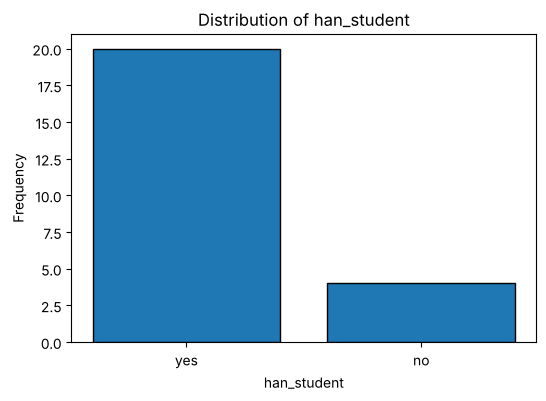

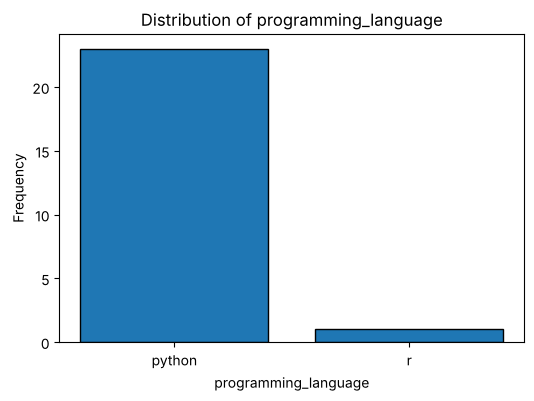

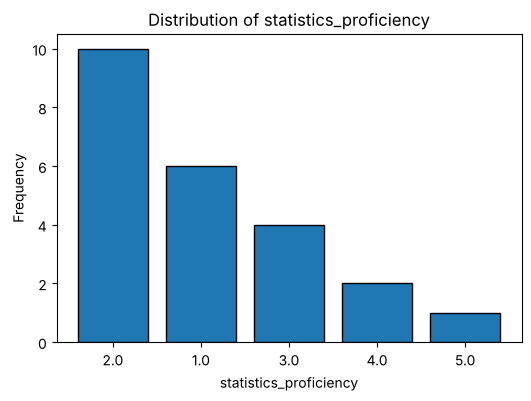

In [6]:
# Bar chart for each categorical variable (slide 17)
for col in categorical:
    counts = data[col].value_counts()
    plt.figure(figsize=(6, 4))
    plt.bar(counts.index.astype(str), counts.values, edgecolor='black')
    plt.title('Distribution of ' + col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

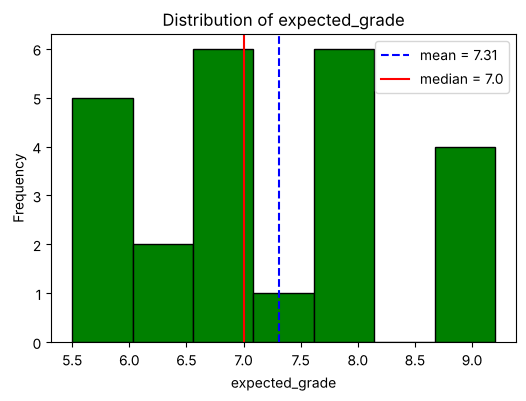

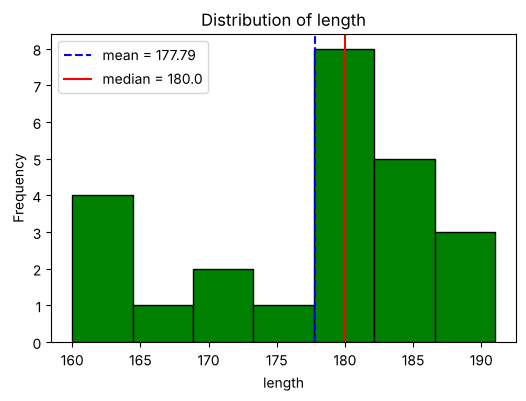

In [7]:
# Histogram for each numerical variable (slide 17), with mean and median as vertical lines
for col in ['expected_grade', 'length']:
    x = data[col]
    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=7, color='green', edgecolor='black')
    plt.axvline(np.mean(x), color='blue', linestyle='--', label='mean = ' + str(round(np.mean(x), 2)))
    plt.axvline(np.median(x), color='red', label='median = ' + str(np.median(x)))
    plt.title('Distribution of ' + col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

**Interpretatie:**
- De staafdiagrammen bevestigen de scheve verhoudingen bij de categorische variabelen: bijna iedereen is HAN-student en gebruikt Python, en statistiekniveau 2 springt eruit.
- **Verwacht cijfer:** de waarden liggen redelijk verspreid tussen 5,5 en 9,2, zonder duidelijke staart. Mean en median liggen dicht bij elkaar.
- **Lengte:** het grootste deel van de groep zit tussen 175 en 190 cm, met een **staart naar links** (enkele studenten van 160–169 cm). Daardoor ligt het gemiddelde links van de mediaan, wat de links-scheve verdeling uit 1B bevestigt.

**Volgende stap:** vraag C. Welke variabele varieert meer? Dat kunnen we niet direct aflezen uit de standaarddeviaties, omdat de eenheden verschillen (cm vs. cijferpunten).

### C) Welke variabele varieert meer: lengte of cijfer?

**Wat:** we vergelijken de standaarddeviaties en zien dat de vergelijking scheef is.
**Waarom:** een SD van 8,99 lijkt veel groter dan 1,10, maar dat komt alleen doordat lengte in centimeters wordt gemeten en rond 178 ligt, terwijl cijfers rond 7 liggen. Voor een eerlijke vergelijking moet de spreiding *relatief* aan het gemiddelde worden uitgedrukt: dat is de **coëfficiënt van variatie** (slide 23). Die berekenen we in de volgende opdracht.

---
## 4. Exercise Coefficient of Variation

**Wat:** we vullen het script `exercise_coefficient_of_variation.py` in en berekenen de CV van `length` en `expected_grade`:

$$CV = \frac{s}{\bar{x}} \cdot 100\%$$

**Waarom:** de CV is eenheidsloos, dus we kunnen variabelen met verschillende eenheden en gemiddelden vergelijken (zoals de aandelen A en B op slide 24).

**Keuze ddof=1?** Ja. De 24 respondenten zijn een steekproef, dus we gebruiken de steekproef-standaarddeviatie *s* (`ddof=1`). Let op: `np.std()` corrigeert standaard **niet**, pandas `.std()` wel (slide 22).

In [8]:
# Computing the coefficient of variation for the minor survey data
import numpy as np
import pandas as pd

# Specify the survey data
data = pd.read_excel('minor_survey.xlsx')

# CV = sample standard deviation / mean * 100%
# ddof=1 -> sample standard deviation (Bessel's correction), because our group is a sample
cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100

# Compute cv for the variables
cv_1 = cv(data['length'])
cv_2 = cv(data['expected_grade'])

# Print the results
print('CV length:', round(cv_1, 2), '%')
print('CV expected_grade:', round(cv_2, 2), '%')

# For comparison: without the correction (ddof=0)
cv_pop = lambda x: np.std(x) / np.mean(x) * 100
print('\n(ddof=0) CV length:', round(cv_pop(data['length']), 2), '%')
print('(ddof=0) CV expected_grade:', round(cv_pop(data['expected_grade']), 2), '%')

CV length: 5.06 %
CV expected_grade: 15.08 %

(ddof=0) CV length: 4.95 %
(ddof=0) CV expected_grade: 14.77 %


**Interpretatie / antwoord op Exercise 2C:**
- **CV lengte ≈ 5,06%**: de standaarddeviatie (8,99 cm) is maar ongeveer 5% van de gemiddelde lengte (177,8 cm).
- **CV verwacht cijfer ≈ 15,08%**: de standaarddeviatie (1,10) is ongeveer 15% van het gemiddelde cijfer (7,31).

**Conclusie:** het **verwachte cijfer varieert relatief ongeveer 3× zo sterk als de lengte**, terwijl de absolute standaarddeviatie van lengte juist veel groter is. Dit is precies de valkuil die de CV oplost. Studenten lijken qua lengte dus veel meer op elkaar dan qua verwachtingen over hun cijfer.

Voor de docent betekent dit dat de verwachtingen over het eindresultaat uiteenlopen (van een 5,5 tot een 9,2). In combinatie met het lage statistiekniveau is het nuttig om vroeg duidelijk te maken wat er nodig is voor een voldoende.
De keuze voor ddof=0 of ddof=1 verandert de conclusie niet (4,95% vs. 14,77%).
**Volgende stap:** de normale verdeling gebruiken om de lengte van de minorgroep te vergelijken met die van Olympische atleten.

---
## 5. Exercise Olympic Athletes

**Wat:** we laden `olympic_athlete_database.csv` (Brightspace, FMSR Class 4), berekenen het gemiddelde (μ) en de standaarddeviatie (σ) van de atletenlengtes en modelleren lengte als normale verdeling $N(\mu, \sigma)$. Daarna beantwoorden we de drie vragen met de cumulatieve verdelingsfunctie (CDF, slide 29–31):

1. $P(X > \text{langste student}) = 1 - \text{norm.cdf}(\max)$
2. $P(X < \text{kortste student}) = \text{norm.cdf}(\min)$
3. $P(\min \le X \le \max) = \text{norm.cdf}(\max) - \text{norm.cdf}(\min)$

**Waarom normale verdeling:** menselijke lengte is bij benadering normaal verdeeld (klokvormig en symmetrisch, slide 28), en het histogram op slide 33 volgt de normale curve goed. Dat controleren we hieronder ook visueel.

> **Let op:** zet `olympic_athlete_database.csv` in dezelfde map als dit notebook. Ik ga ervan uit dat de kolom met lengte `height` heet. Heet hij anders, pas dan de kolomnaam aan in de eerste regel onder `# Heights of the athletes`. Ontbrekende lengtes halen we weg met `.dropna()`.

In [ ]:
survey = pd.read_excel('minor_survey.xlsx')
min_student = np.min(survey['length'])   # shortest student in the minor group
max_student = np.max(survey['length'])   # tallest student in the minor group
print('Kortste student:', min_student, 'cm | Langste student:', max_student, 'cm')

athletes = pd.read_csv('olympic_athlete_database.csv')

# Heights of the athletes
heights = athletes['height'].dropna()    # remove missing heights
heights = heights[heights > 0]           # remove impossible heights (0)

mu = np.mean(heights)
sigma = np.std(heights, ddof=1)
print('Aantal atleten met een lengte:', len(heights))
print('Gemiddelde lengte (mu):', round(mu, 2), 'cm')
print('Standaarddeviatie (sigma):', round(sigma, 2), 'cm')

**Controle normaliteit:** we tekenen een genormaliseerd histogram (`density=True`) van de atletenlengtes, zoals op slide 33. Is het klokvormig en symmetrisch (mean ≈ median), dan is het normale model verantwoord.

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.hist(heights, bins=35, density=True, edgecolor='black', label='Olympian heights')
plt.axvline(min_student, color='red', linestyle='--', label='Shortest / tallest student')
plt.axvline(max_student, color='red', linestyle='--')
plt.title('Heights of Olympians (Mean=' + str(round(mu, 2)) + ', std=' + str(round(sigma, 2)) + ')')
plt.xlabel('Height (cm)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

print('Mean:', round(mu, 2), '| Median:', np.median(heights))

In [ ]:
from scipy.stats import norm

# z-scores (step 1 of the manual method with the z-table, slide 31)
z_max = (max_student - mu) / sigma
z_min = (min_student - mu) / sigma
print('z-score langste student:', round(z_max, 2))
print('z-score kortste student:', round(z_min, 2), '\n')

# 1) P(athlete taller than the tallest student) -> area to the RIGHT
p_taller = 1 - norm.cdf(max_student, mu, sigma)

# 2) P(athlete shorter than the shortest student) -> area to the LEFT
p_shorter = norm.cdf(min_student, mu, sigma)

# 3) P(shortest student <= athlete <= tallest student) -> area IN BETWEEN
p_within = norm.cdf(max_student, mu, sigma) - norm.cdf(min_student, mu, sigma)

print('1) P(atleet langer dan', max_student, 'cm):', round(p_taller * 100, 2), '%')
print('2) P(atleet korter dan', min_student, 'cm):', round(p_shorter * 100, 2), '%')
print('3) P(atleet tussen', min_student, 'en', max_student, 'cm):', round(p_within * 100, 2), '%')
print('Controle (som = 100%):', round((p_taller + p_shorter + p_within) * 100, 2), '%')

# Empirical check: actual share of athletes in the data (counting like slide 10)
print('\nTer vergelijking: het werkelijke aandeel in de dataset')
print('   langer dan', max_student, 'cm:', round((heights > max_student).sum() / len(heights) * 100, 2), '%')
print('   korter dan', min_student, 'cm:', round((heights < min_student).sum() / len(heights) * 100, 2), '%')
print('   daartussen:', round(((heights >= min_student) & (heights <= max_student)).sum() / len(heights) * 100, 2), '%')

**Interpretatie (vul aan met jouw uitkomsten):**
- De minorgroep loopt van **160 cm** (kortste) tot **191 cm** (langste). Dat zijn de grenzen *a* en *b* uit $P(a \le X \le b)$.
- **Vraag 1** is de oppervlakte *rechts* van 191 cm onder de normale curve van de atleten. Omdat `norm.cdf()` altijd de oppervlakte *links* van een waarde geeft, rekenen we $1 - \text{cdf}$.
- **Vraag 2** is de oppervlakte *links* van 160 cm, dus direct `norm.cdf(160)`.
- **Vraag 3** is de oppervlakte *tussen* 160 en 191 cm: cdf(191) − cdf(160). De drie kansen moeten samen 1 (100%) zijn; dat controleert de code.
- De **z-scores** laten zien hoeveel standaarddeviaties de langste en kortste student van de gemiddelde atleet afliggen. Dat is dezelfde stap die je met de z-tabel zou doen (slide 31).
- De **empirische controle** (werkelijk aandeel in de dataset) laat zien hoe goed het normale model past. Liggen model en werkelijkheid dicht bij elkaar, dan is de aanname van normaliteit terecht. Grote verschillen wijzen op dikkere staarten dan de normale verdeling voorspelt (bijv. door basketballers of turners).

**Conclusie:** omdat het bereik van de minorgroep (160–191 cm) het grootste deel van de klokvorm rond het atletengemiddelde afdekt, verwachten we dat de meeste atleten binnen dat bereik vallen en maar een klein deel erbuiten. De precieze percentages volgen uit de output hierboven.

---
## 6. Samenvatting

| Opdracht | Antwoord |
|---|---|
| 1A – centrale tendens | 83% HAN-student, 96% Python, statistiekniveau modus = 2; verwacht cijfer mean 7,31 / median 7,0; lengte mean 177,8 / median 180 cm |
| 1B – mean of median | Hangt af van de data. Cijfer is vrijwel symmetrisch → mean prima. Lengte is iets links-scheef → median iets beter. Bij scheefheid/uitschieters: median |
| 2A – spreiding | Cijfer: range 3,7, s = 1,10. Lengte: range 31 cm, s = 8,99 cm (ddof=1) |
| 2B – visualisatie | Staafdiagrammen (categorisch) en histogrammen (numeriek); lengte heeft een linkerstaart |
| 2C / CV | CV lengte ≈ 5,1%, CV cijfer ≈ 15,1% → **het cijfer varieert relatief ~3× meer** |
| Olympic athletes | Kansen via `norm.cdf` met μ en σ uit de atletendata; grenzen 160 en 191 cm |